# Testing Image Segmentation Models from Hugging Face

In [2]:
import numpy as np
from PIL import Image
from huggingface_hub import hf_hub_download
import onnxruntime as ort

In [3]:
# Download the model
model_path = hf_hub_download(repo_id="HakaiInstitute/mussel-rgb", filename="model.onnx")

# Load the model
session = ort.InferenceSession(model_path)

model.onnx:   0%|          | 0.00/179M [00:00<?, ?B/s]

In [4]:
# ImageNet normalization parameters
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

In [5]:
# Preprocess your RGB image
def preprocess(image):
    """
    Preprocess RGB image for model input
    image: numpy array of shape [height, width, 3] with pixel values 0-255
    """
    # Normalize to 0-1
    image = image.astype(np.float32) / 255.0
    
    # Apply ImageNet normalization
    image = (image - mean) / std
    
    # Reshape to model input format [batch, channels, height, width]
    image = np.transpose(image, (2, 0, 1))  # HWC to CHW
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    
    return image

In [24]:
# Load and preprocess image
image = np.array(Image.open("mussels2.jpg").convert("RGB"))
preprocessed = preprocess(image)

In [25]:
# Run inference
input_name = session.get_inputs()[0].name
output = session.run(None, {input_name: preprocessed.astype(np.float32)})

In [26]:
# Postprocess to get binary mask
logits = output[0]
prediction = np.argmax(logits, axis=1).squeeze(0).astype(np.uint8)
# Result: 0=background, 1=mussels

In [27]:
# Check if mussels have been detected
print(prediction[prediction == 1])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


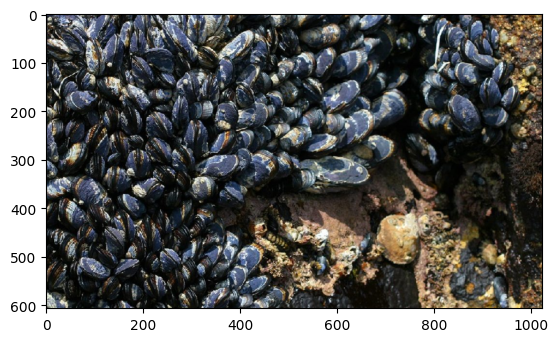

In [28]:
import matplotlib.pyplot as plt

plt.imshow(image)

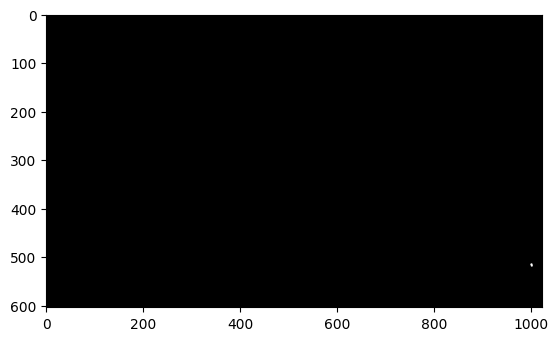

In [30]:
plt.imshow(prediction, vmin=0, vmax=1, cmap='gray')